In [2]:
# Import required libraries

import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import plot_tree
from src.preprocessing import preprocess_data
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report
)
from sklearn.preprocessing import label_binarize
import numpy as np

In [3]:
# Load and preprocess data

X_train, X_test, y_train, y_test = preprocess_data(
    "../data/online_gaming_behavior_dataset.csv"
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# Check class distribution
print("Class distribution:\n", y_train.value_counts(normalize=True))

Training shape: (37203, 18)
Testing shape: (8007, 18)
Class distribution:
 EngagementLevel
Medium    0.333333
Low       0.333333
High      0.333333
Name: proportion, dtype: float64


In [4]:
print(y_train.unique())
print(y_test.unique())

<StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str


In [5]:
# Train Decision Tree
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize model
dt = DecisionTreeClassifier(random_state=42)

# Grid Search
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',   # best for imbalanced data
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best model
dt_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV Score: 0.9131348987281147


In [6]:
# Predictions
y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)  # For ROC AUC

In [7]:
# Evaluation Metrics
# Accuracy
acc = accuracy_score(y_test, y_pred)
# Precision (weighted)
prec = precision_score(y_test, y_pred, average='weighted')
# Recall (weighted)
rec = recall_score(y_test, y_pred, average='weighted')
# F1 Score (weighted)
f1 = f1_score(y_test, y_pred, average='weighted')

In [8]:
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9131
Precision: 0.9129
Recall: 0.9131
F1 Score: 0.9129


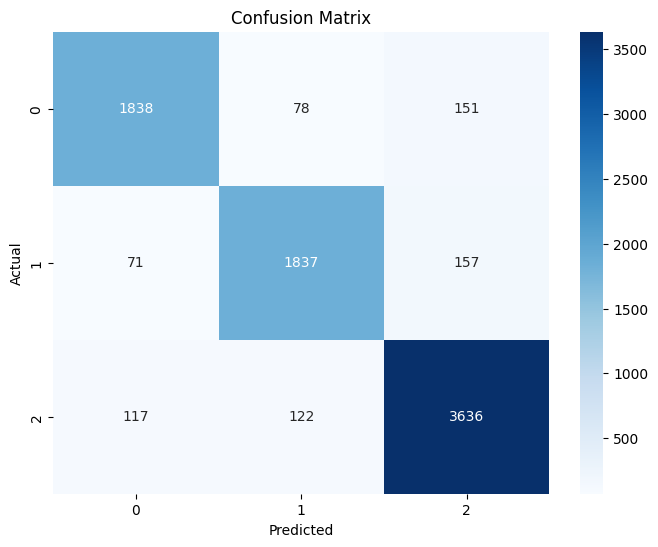

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [10]:
# ROC AUC - One-vs-Rest
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
roc_auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
print(f"ROC AUC (One-vs-Rest, Macro): {roc_auc:.4f}")

ROC AUC (One-vs-Rest, Macro): 0.9377


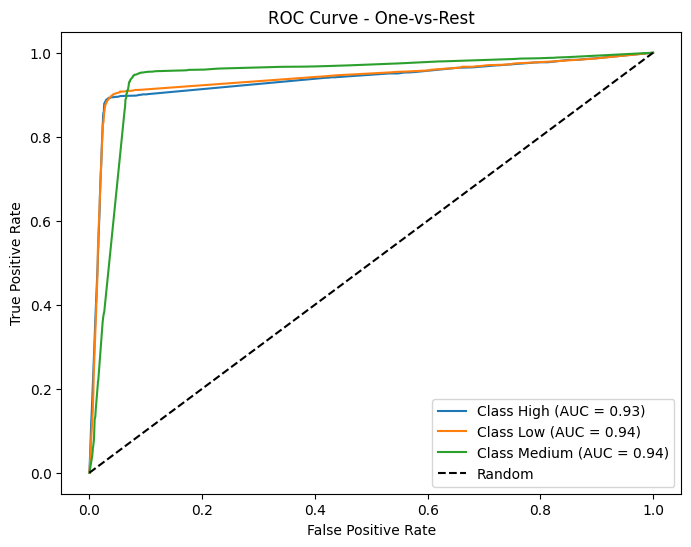

In [11]:
# ROC Curve for each class
plt.figure(figsize=(8,6))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - One-vs-Rest')
plt.legend(loc='lower right')
plt.show()

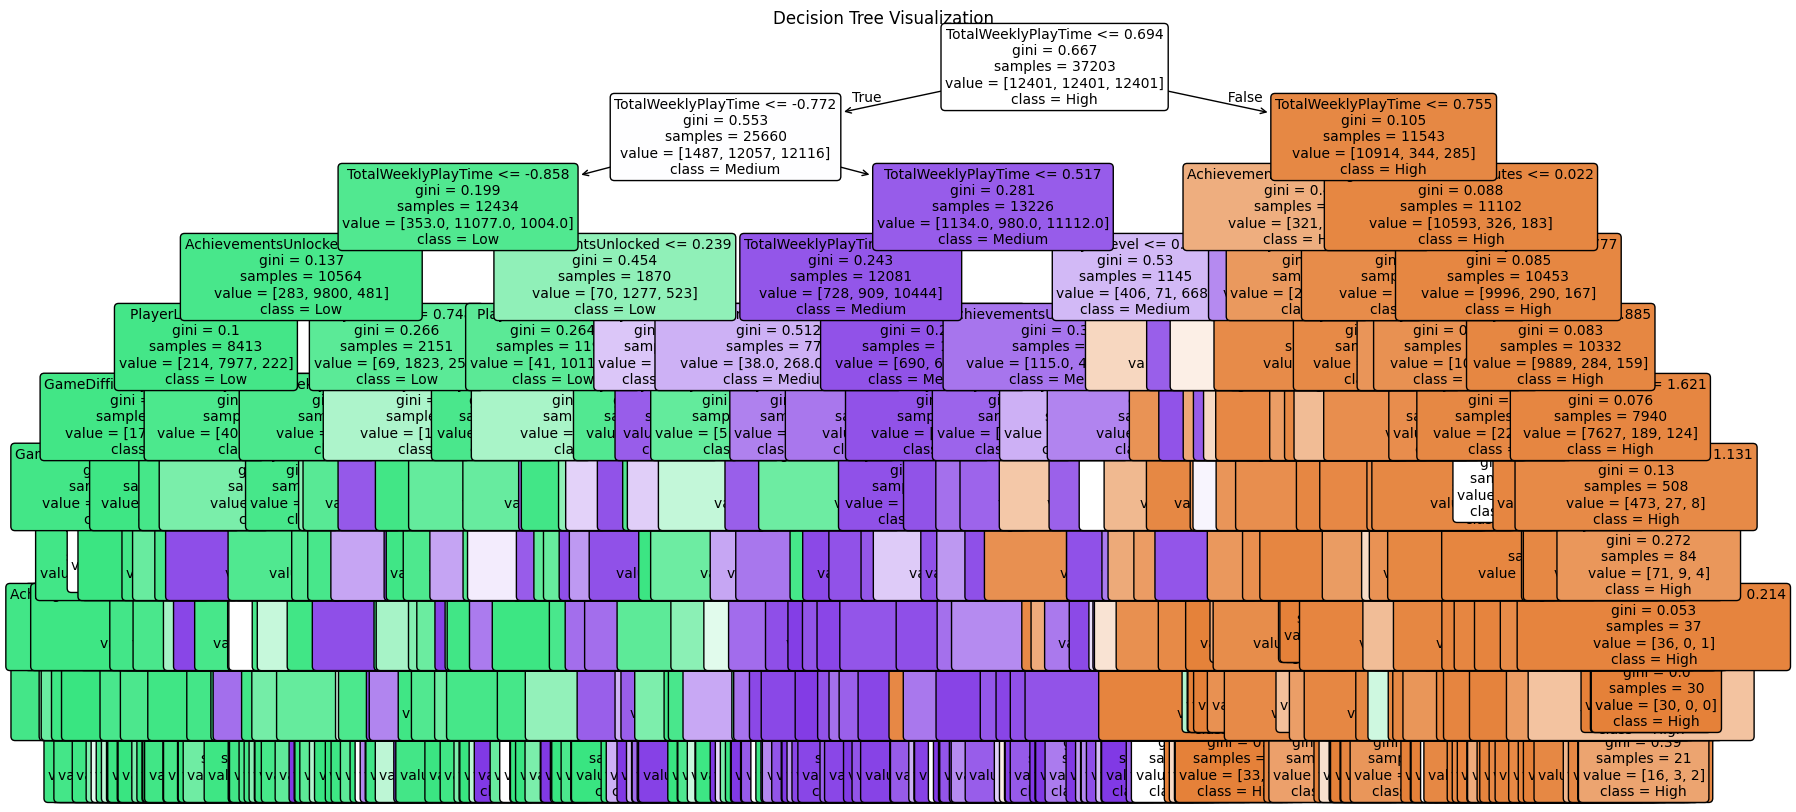

In [12]:
# Visualize Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X_train.columns, class_names=[str(c) for c in classes],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()

In [13]:
# All evaluation metrics together
print("\n========== FINAL MODEL EVALUATION ==========\n")

print(f"Accuracy        : {acc:.4f}")
print(f"Precision       : {prec:.4f}")
print(f"Recall          : {rec:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"ROC-AUC (OvR)   : {roc_auc}")

print("\n---------- Classification Report ----------\n")
print(classification_report(y_test, y_pred))

print("===========================================\n")


========== FINAL MODEL EVALUATION ==========

Accuracy        : 0.9131
Precision       : 0.9129
Recall          : 0.9131
F1 Score        : 0.9129
ROC-AUC (OvR)   : 0.9377457299622155

---------- Classification Report ----------

              precision    recall  f1-score   support

        High       0.91      0.89      0.90      2067
         Low       0.90      0.89      0.90      2065
      Medium       0.92      0.94      0.93      3875

    accuracy                           0.91      8007
   macro avg       0.91      0.91      0.91      8007
weighted avg       0.91      0.91      0.91      8007




In [14]:
# Function to predict engagement level for a new player
def predict_new_player(input_data, model, columns):
    """
    Predict engagement level for a new player without scaling
    """

    # Convert input to DataFrame
    df = pd.DataFrame([input_data])

    # Feature engineering
    if 'AvgSessionDurationMinutes' in df.columns and 'SessionsPerWeek' in df.columns:
        df['TotalWeeklyPlayTime'] = (
            df['AvgSessionDurationMinutes'] * df['SessionsPerWeek']
        )

    # Encoding categorical features
    df = pd.get_dummies(df, drop_first=True)

    # Align columns with training data
    df = df.reindex(columns=columns, fill_value=0)

    # Prediction
    prediction = model.predict(df)
    probabilities = model.predict_proba(df)

    return prediction[0], probabilities[0]

In [15]:
# Example input
sample_player = {
    'Age': 21,
    'Gender': 'Male',
    'Location': 'Other',
    'PlayTimeHours': 1,
    'InGamePurchases': 0,
    'GameDifficulty': 'Medium',
    'AvgSessionDurationMinutes': 50,
    'PlayerLevel': 10,
    'AchievementsUnlocked': 5,
    'SessionsPerWeek': 4,
    'GameGenre': 'Action'
}

pred, prob = predict_new_player(
    sample_player,
    dt_model,
    X_train.columns  
)

print("Predicted Engagement Level:", pred)
print("Prediction Probabilities:", prob)

Predicted Engagement Level: High
Prediction Probabilities: [1. 0. 0.]


In [19]:
# Save results to CSV

results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average='weighted'),
    "Recall": recall_score(y_test, y_pred, average='weighted'),
    "F1-score": f1_score(y_test, y_pred, average='weighted'),
    "ROC_AUC": roc_auc
}

results_df = pd.DataFrame([results])

results_df.to_csv("../results/decision_tree.csv", index=False)